# The Public-Company Founder: A Tax Bill You Can't Pay Without Moving the Stock

**Scenario.** A founder owns 20% of a publicly traded company with a market cap of \$5B. Over one year the company grows to \$7B. The founder's paper gain is \$400M and a 20% annual mark-to-market tax produces an \$80M cash bill. He has no other liquid wealth — his stake *is* his wealth.

He has to sell stock to pay the tax. The question this notebook tries to answer: **how much of the tax does he actually pay, once you include the price impact of forcing \$80M of insider supply through a stock that trades \$30–\$50M a day?**

Spoiler: the headline 20% tax rate on his paper gain ends up costing closer to 30% — about 1.5× the nominal rate — because every dollar of forced selling permanently lowers the value of the stock he still owns.

## What we use as inputs

Three empirical regularities anchor the model:

1. **Liquidity.** For listed companies in the \$5–10B market-cap range, average daily dollar volume is roughly **0.6%–0.8% of market cap**. (The S&P MidCap 400 now starts at \$8B; a \$5B name is below that band, in the lower-mid / small-cap segment, where turnover is thinner.) We use 0.7% as a baseline.
2. **Daily volatility ~ 2%.** Mid-cap annualized volatility is typically 30–40%, so daily σ = 30%/√252 ≈ 1.9%. We use 2%.
3. **Square-root price impact (Almgren et al. 2005; Said 2022 survey).** A metaorder of size \$Q\$ on a stock with daily volume \$V\$ moves price by approximately
$$\Delta P / P \approx Y \cdot \sigma \cdot \sqrt{Q/V}, \qquad Y \approx 1.$$
   This holds across equities, futures, options, and crypto. The total displacement decomposes into a *temporary* part that decays after the trade and a *permanent* part typically estimated at ~1/3 of the total. For insider sales we add a modest signaling discount (the market knows it is an insider liquidating).
4. **Rule 144 dribble cap.** Insider affiliates can sell at most max(1% of shares outstanding, prior-4-week average weekly volume) per rolling three-month period. We check whether the tax-driven sale even *fits* inside this cap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# --- Scenario ------------------------------------------------------
founder_ownership = 0.20
start_market_cap  = 5_000_000_000     # year-start
end_market_cap    = 7_000_000_000     # year-end
tax_rate          = 0.20

# --- Market microstructure ----------------------------------------
adv_pct           = 0.007             # daily dollar volume as % of market cap
sigma_daily       = 0.02              # daily volatility
Y                 = 1.0               # square-root impact coefficient
perm_fraction     = 0.33              # share of impact that is permanent (rest decays)
insider_signal    = 0.02              # extra permanent discount from known insider supply

# --- Sale plan ----------------------------------------------------
trading_days_year = 252
sale_horizon_days = 60                # ~one calendar quarter; close to Rule-144 cycle
rule144_quarter_cap_pct = 0.01        # 1% of shares outstanding per rolling 3 months

## Step 1 — the headline tax bill

In [3]:
stake_start = founder_ownership * start_market_cap
stake_end   = founder_ownership * end_market_cap
paper_gain  = stake_end - stake_start
tax_owed    = tax_rate * paper_gain

print(f"Founder stake at year start:    ${stake_start:>15,.0f}")
print(f"Founder stake at year end:      ${stake_end:>15,.0f}")
print(f"Paper gain on the year:         ${paper_gain:>15,.0f}")
print(f"Tax owed at 20%:                ${tax_owed:>15,.0f}")

Founder stake at year start:    $  1,000,000,000
Founder stake at year end:      $  1,400,000,000
Paper gain on the year:         $    400,000,000
Tax owed at 20%:                $     80,000,000


## Step 2 — how big is that sale relative to normal trading?

In [4]:
adv_dollar = adv_pct * end_market_cap                    # average daily $ volume
horizon_volume = adv_dollar * sale_horizon_days          # cumulative $ traded over horizon

naive_shares_to_sell_pct = tax_owed / end_market_cap     # as % of total shares outstanding
tax_vs_daily_vol         = tax_owed / adv_dollar         # multiple of one day's volume
tax_vs_horizon_vol       = tax_owed / horizon_volume     # fraction of horizon volume

print(f"Average daily dollar volume:      ${adv_dollar:>15,.0f}")
print(f"Volume over {sale_horizon_days}-day horizon:        ${horizon_volume:>15,.0f}")
print()
print(f"Tax bill as % of company:         {naive_shares_to_sell_pct:>15.2%}")
print(f"Tax bill in days of volume:       {tax_vs_daily_vol:>15.1f} days")
print(f"Tax bill as % of horizon volume:  {tax_vs_horizon_vol:>15.2%}")
print()
weekly_volume = adv_dollar * 5
rule144_cap_one_pct  = rule144_quarter_cap_pct * end_market_cap
rule144_cap_weekly   = weekly_volume                                   # avg weekly $ volume
rule144_cap_per_quarter = max(rule144_cap_one_pct, rule144_cap_weekly)
print(f"Rule 144 1%-of-shares cap:          ${rule144_cap_one_pct:>13,.0f}")
print(f"Rule 144 weekly-volume cap:         ${rule144_cap_weekly:>13,.0f}")
print(f"Effective Rule 144 cap (greater):   ${rule144_cap_per_quarter:>13,.0f}")
print(f"Tax bill / Rule-144 cap:            {tax_owed/rule144_cap_per_quarter:>15.2f}x  "
      f"(>1 means more than one quarter required)")

Average daily dollar volume:      $     49,000,000
Volume over 60-day horizon:        $  2,940,000,000

Tax bill as % of company:                   1.14%
Tax bill in days of volume:                   1.6 days
Tax bill as % of horizon volume:            2.72%

Rule 144 1%-of-shares cap:          $   70,000,000
Rule 144 weekly-volume cap:         $  245,000,000
Effective Rule 144 cap (greater):   $  245,000,000
Tax bill / Rule-144 cap:                       0.33x  (>1 means more than one quarter required)


## Step 3 — predicted price impact under the square-root law

Total impact = mechanical impact from order size + insider signaling. The mechanical piece scales like √(Q/V) per Almgren. The permanent piece is roughly 1/3 of the total — that's what stays in the price after the metaorder finishes. The signaling piece is pure permanent.

In [5]:
def price_impact(dollar_size, daily_volume=adv_dollar, sigma=sigma_daily, y=Y,
                 perm=perm_fraction, signal=insider_signal):
    """Return (total_impact_fraction, permanent_impact_fraction). Positive number = price drops by that much."""
    if dollar_size <= 0:
        return 0.0, 0.0
    mechanical = y * sigma * np.sqrt(dollar_size / daily_volume)
    total = mechanical + signal
    permanent = perm * mechanical + signal
    return total, permanent

total_imp, perm_imp = price_impact(tax_owed)
print(f"Total price impact during sale:     {total_imp:.2%}")
print(f"Permanent component (after sale):   {perm_imp:.2%}")

Total price impact during sale:     4.56%
Permanent component (after sale):   2.84%


## Step 4 — the founder has to sell *more* than the tax to net the tax

If he sells at an average price discounted by ~½ of the total impact (the linear-VWAP approximation: the first share goes off near the top, the last share near the bottom), then he nets `dollars_sold × (1 − total_impact/2)`. To net \$80M he has to sell more than \$80M of stock. We solve for the actual amount.

In [6]:
def shortfall(gross_dollars_sold, target_net=tax_owed):
    total_imp, _ = price_impact(gross_dollars_sold)
    net = gross_dollars_sold * (1 - total_imp / 2)   # average execution at midpoint of impact
    return net - target_net

# Solve gross sale required to net the tax
gross_sale = brentq(shortfall, tax_owed, tax_owed * 5)
total_imp_realized, perm_imp_realized = price_impact(gross_sale)

print(f"Gross stock sold (pre-impact dollars): ${gross_sale:>15,.0f}")
print(f"Net cash received (= tax owed):        ${tax_owed:>15,.0f}")
print(f"Friction (over-selling above the tax): ${gross_sale - tax_owed:>15,.0f}  "
      f"({(gross_sale - tax_owed)/tax_owed:.1%} of the tax)")
print(f"Realized total impact during sale:     {total_imp_realized:.2%}")
print(f"Realized permanent impact:             {perm_imp_realized:.2%}")

Gross stock sold (pre-impact dollars): $     81,877,163
Net cash received (= tax owed):        $     80,000,000
Friction (over-selling above the tax): $      1,877,163  (2.3% of the tax)
Realized total impact during sale:     4.59%
Realized permanent impact:             2.85%


## Step 5 — the loss on the shares he still holds

After the sale, the permanent impact stays in the stock price. His *remaining* shares are worth permanently less. That value destruction is not on his tax return, but it is the largest hidden cost of this whole exercise.

In [7]:
fraction_sold = gross_sale / end_market_cap
remaining_ownership = founder_ownership - fraction_sold
remaining_value_pre_impact  = remaining_ownership * end_market_cap
remaining_value_post_impact = remaining_ownership * end_market_cap * (1 - perm_imp_realized)
value_destruction_remaining = remaining_value_pre_impact - remaining_value_post_impact

print(f"Ownership sold to pay tax:           {fraction_sold:.2%} of the company")
print(f"Remaining ownership:                 {remaining_ownership:.2%}")
print()
print(f"Remaining stake before impact:       ${remaining_value_pre_impact:>15,.0f}")
print(f"Remaining stake after impact:        ${remaining_value_post_impact:>15,.0f}")
print(f"Value destroyed on remaining stake:  ${value_destruction_remaining:>15,.0f}")

Ownership sold to pay tax:           1.17% of the company
Remaining ownership:                 18.83%

Remaining stake before impact:       $  1,318,122,837
Remaining stake after impact:        $  1,280,514,767
Value destroyed on remaining stake:  $     37,608,071


## Step 6 — putting it all together: the real cost vs the headline tax

In [8]:
cash_to_treasury = tax_owed
friction_overshoot = gross_sale - tax_owed
value_destroyed = value_destruction_remaining
total_economic_cost = cash_to_treasury + friction_overshoot + value_destroyed

effective_tax_rate_on_gain = total_economic_cost / paper_gain

summary = pd.DataFrame([
    ('Cash paid to Treasury',          cash_to_treasury),
    ('Sale friction (over-sold $)',     friction_overshoot),
    ('Value destroyed on remaining stake', value_destroyed),
    ('TOTAL economic cost to founder',  total_economic_cost),
    ('-- as % of paper gain --',        effective_tax_rate_on_gain * paper_gain),
], columns=['Component', 'Amount ($)'])

print(summary.to_string(index=False, formatters={'Amount ($)': lambda x: f'${x:>14,.0f}'}))
print()
print(f"Nominal tax rate on paper gain:    {tax_rate:.0%}")
print(f"Effective rate (cost / gain):      {effective_tax_rate_on_gain:.1%}")
print(f"Hidden multiplier:                 {effective_tax_rate_on_gain/tax_rate:.2f}x the nominal rate")

                         Component      Amount ($)
             Cash paid to Treasury $    80,000,000
       Sale friction (over-sold $) $     1,877,163
Value destroyed on remaining stake $    37,608,071
    TOTAL economic cost to founder $   119,485,233
          -- as % of paper gain -- $   119,485,233

Nominal tax rate on paper gain:    20%
Effective rate (cost / gain):      29.9%
Hidden multiplier:                 1.49x the nominal rate


## Charts

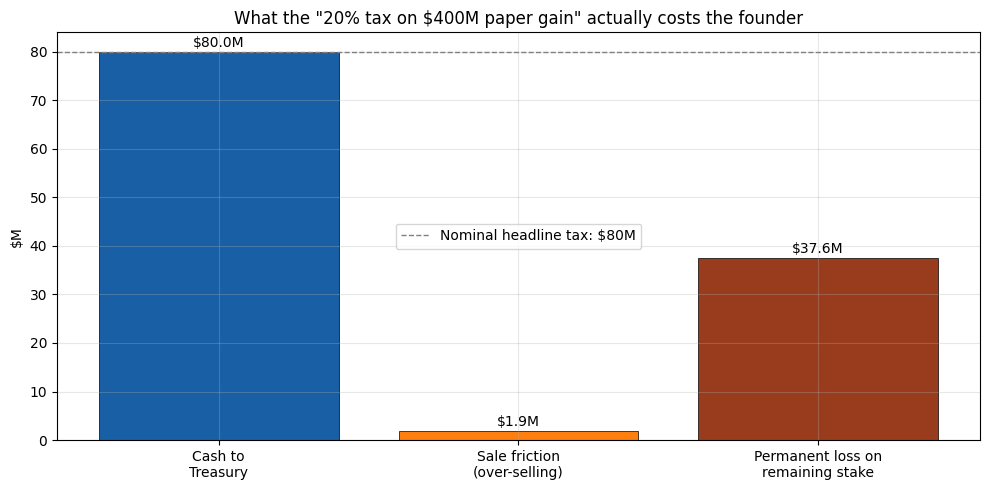

In [9]:
labels = ['Cash to\nTreasury', 'Sale friction\n(over-selling)', 'Permanent loss on\nremaining stake']
values = [cash_to_treasury/1e6, friction_overshoot/1e6, value_destruction_remaining/1e6]
colors = ['#185FA5', '#ff7f0e', '#993C1D']

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'${v:,.1f}M', ha='center', fontsize=10)
ax.set_title(f'What the \"20% tax on $400M paper gain\" actually costs the founder')
ax.set_ylabel('$M')
ax.axhline(paper_gain * tax_rate / 1e6, color='gray', linestyle='--', linewidth=1,
           label=f'Nominal headline tax: ${paper_gain*tax_rate/1e6:.0f}M')
ax.legend()
plt.tight_layout()
plt.show()

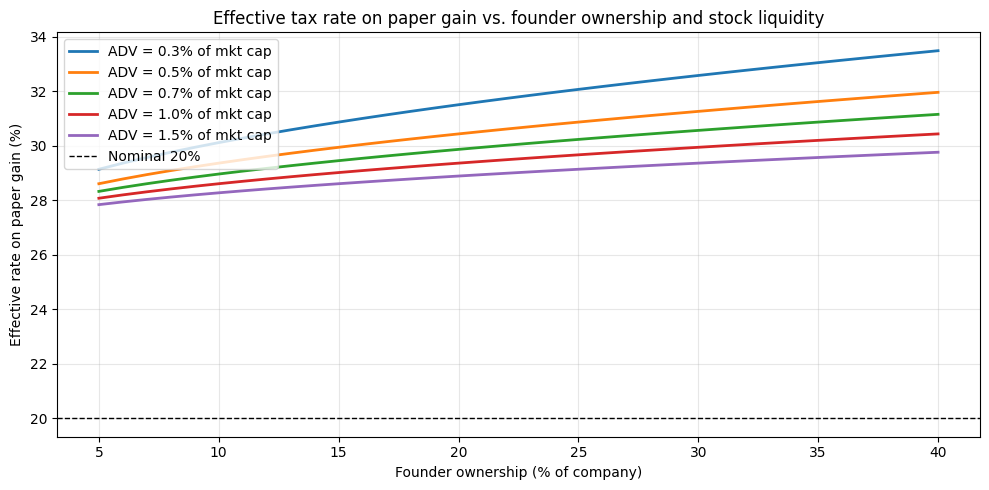

In [10]:
# Sensitivity: effective cost as a function of order size (founder ownership) and ADV%
ownerships = np.linspace(0.05, 0.40, 36)
adv_pcts   = np.array([0.003, 0.005, 0.007, 0.010, 0.015])

fig, ax = plt.subplots()
for a in adv_pcts:
    eff_rates = []
    for own in ownerships:
        gain = own * (end_market_cap - start_market_cap)
        tax  = tax_rate * gain
        adv_d = a * end_market_cap
        try:
            gs = brentq(lambda g: g * (1 - (Y*sigma_daily*np.sqrt(g/adv_d) + insider_signal)/2) - tax,
                        tax, tax * 10)
        except ValueError:
            eff_rates.append(np.nan); continue
        ti = Y*sigma_daily*np.sqrt(gs/adv_d) + insider_signal
        pi = perm_fraction*Y*sigma_daily*np.sqrt(gs/adv_d) + insider_signal
        rem_own = own - gs/end_market_cap
        vd = rem_own*end_market_cap*pi
        cost = tax + (gs - tax) + vd
        eff_rates.append(cost/gain)
    ax.plot(ownerships*100, np.array(eff_rates)*100, label=f'ADV = {a*100:.1f}% of mkt cap', linewidth=2)

ax.axhline(tax_rate*100, color='black', linestyle='--', linewidth=1, label=f'Nominal {tax_rate:.0%}')
ax.set_title('Effective tax rate on paper gain vs. founder ownership and stock liquidity')
ax.set_xlabel('Founder ownership (% of company)')
ax.set_ylabel('Effective rate on paper gain (%)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

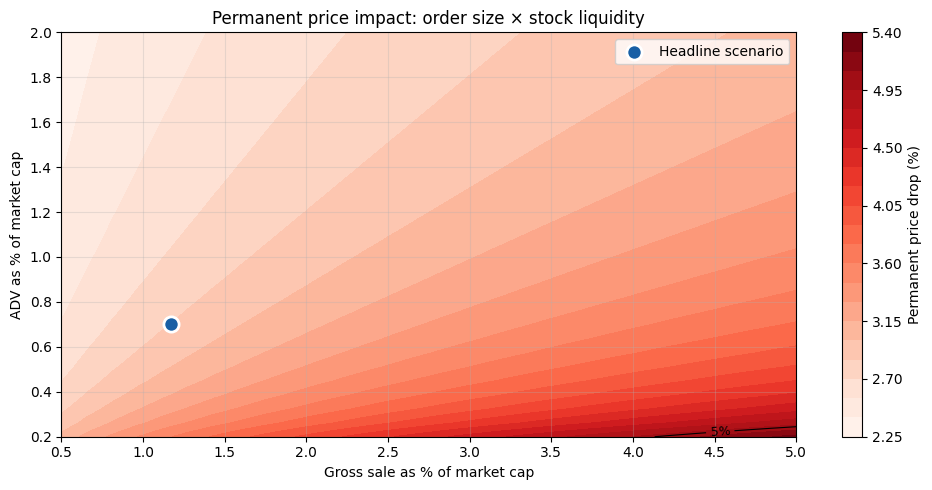

In [11]:
# Permanent price impact contour across (order size, ADV)
order_pcts = np.linspace(0.005, 0.05, 30)        # gross sale as % of market cap
adv_grid   = np.linspace(0.002, 0.020, 30)        # ADV as % of market cap
OG, AG = np.meshgrid(order_pcts, adv_grid)
PERM = perm_fraction * Y * sigma_daily * np.sqrt(OG / AG) + insider_signal

fig, ax = plt.subplots()
cs = ax.contourf(OG*100, AG*100, PERM*100, levels=20, cmap='Reds')
cl = ax.contour(OG*100, AG*100, PERM*100, levels=[2, 5, 10, 15, 20], colors='black', linewidths=0.8)
ax.clabel(cl, inline=True, fontsize=9, fmt='%d%%')
cbar = plt.colorbar(cs, ax=ax)
cbar.set_label('Permanent price drop (%)')
ax.scatter([gross_sale/end_market_cap*100], [adv_pct*100], color='#185FA5', s=120, zorder=5,
           edgecolor='white', linewidth=2, label='Headline scenario')
ax.set_title('Permanent price impact: order size × stock liquidity')
ax.set_xlabel('Gross sale as % of market cap')
ax.set_ylabel('ADV as % of market cap')
ax.legend()
plt.tight_layout()
plt.show()

 Year  Mkt cap end  Ownership  Tax owed  Economic cost
    1       7000.0       18.8      80.0          119.5
    2       7510.2       18.5      26.4           61.9
    3       8057.8       18.1      27.8           65.1
    4       8645.9       17.8      29.2           68.5
    5       9277.2       17.5      30.8           72.1
    6       9955.0       17.2      32.4           75.8


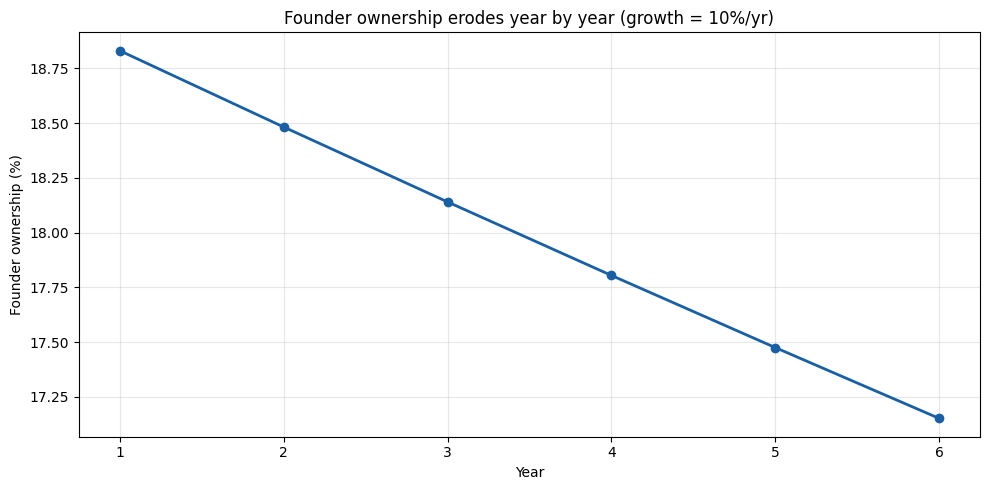

In [12]:
# Multi-year compounding: if every year the company grows X% and he has to sell to pay tax
years = 6
growth_per_year = 0.10
mc = end_market_cap                        # start the multi-year roll forward from year-end
own = founder_ownership - fraction_sold    # he's already sold to pay year-1 tax in our scenario
running_cash = tax_owed                    # year-1 tax already paid in cash
rows = [(1, mc, own, tax_owed, total_economic_cost)]
for y in range(2, years+1):
    new_mc = mc * (1 + growth_per_year)
    gain   = own * (new_mc - mc)
    tax    = tax_rate * gain
    adv_d  = adv_pct * new_mc
    try:
        gs = brentq(lambda g: g * (1 - (Y*sigma_daily*np.sqrt(g/adv_d) + insider_signal)/2) - tax,
                    tax, tax * 10)
    except ValueError:
        gs = tax
    ti = Y*sigma_daily*np.sqrt(gs/adv_d) + insider_signal
    pi = perm_fraction*Y*sigma_daily*np.sqrt(gs/adv_d) + insider_signal
    sold_frac = gs / new_mc
    rem_own   = own - sold_frac
    vd = rem_own * new_mc * pi
    econ_cost = tax + (gs - tax) + vd
    mc  = new_mc * (1 - pi)              # post-sale permanent price level
    own = rem_own
    rows.append((y, mc, own, tax, econ_cost))

trace = pd.DataFrame(rows, columns=['Year', 'Mkt cap end', 'Ownership', 'Tax owed', 'Economic cost'])
trace[['Mkt cap end','Tax owed','Economic cost']] /= 1e6
trace['Ownership'] *= 100
print(trace.round(1).to_string(index=False))

fig, ax = plt.subplots()
ax.plot(trace['Year'], trace['Ownership'], marker='o', linewidth=2, color='#185FA5')
ax.set_title(f'Founder ownership erodes year by year (growth = {growth_per_year:.0%}/yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Founder ownership (%)')
plt.tight_layout()
plt.show()

## Takeaways

1. **The $80M nominal tax bill costs the founder ~$120M in real economic terms** — half again as much as the cash paid to the Treasury. The hidden \$38M is the permanent value destroyed on the ~18.8% stake he still holds after the sale, plus a small sale-friction overshoot.
2. **The effective tax rate on his paper gain is ~30%, not 20%.** And it climbs sharply as the company gets smaller, the founder owns more, or the stock is less liquid — exactly the households the proposal is supposed to target.
3. **Rule 144 doesn't bind for a normally liquid \$5–7B stock** (the weekly-volume cap is roughly \$245M, comfortably above the \$80M sale). But it *does* bind for thinly traded names: cut ADV below ~0.3% of market cap and the founder runs out of legal selling capacity inside one quarter and has to push the sale across multiple quarters.
4. **Other shareholders pay too.** The permanent price drop applies to *everyone* who owns the stock — index funds, pension plans, retail. A wealth tax on the founder is, in part, a value transfer from every other holder of the same security to the Treasury.
5. **Compounding.** If the company keeps growing, the same dance repeats every year. Each year's tax bill forces another insider sale; ownership erodes monotonically. The founder loses control of the company on a fixed schedule independent of business performance.

## Caveats

- The square-root law is a robust empirical regularity but the *coefficient* Y is asset- and venue-specific. Almgren et al. estimate it near 1 for U.S. equities; other authors find Y in the 0.5–1.5 range. The numbers above scale linearly with Y.
- The 2% "insider signaling" permanent discount is a stylized estimate. Pre-announced 10b5-1 plan sales attract a smaller discount; surprise insider supply attracts a larger one.
- We assume the sale is executed cleanly over the chosen horizon. In practice, brokers spread insider blocks via dark pools and accelerated programs to minimize impact — but the *permanent* component is structural and cannot be hidden.

## Sources

- Almgren, R., Thum, C., Hauptmann, E., & Li, H. (2005). Direct estimation of equity market impact. ([PDF](https://www.cis.upenn.edu/~mkearns/finread/costestim.pdf))
- Said, E. (2022). Market Impact: Empirical Evidence, Theory and Practice. ([arXiv 2205.07385](https://arxiv.org/pdf/2205.07385))
- SEC Rule 144 — selling restricted and control securities ([SEC.gov](https://www.sec.gov/reports/rule-144-selling-restricted-control-securities))
- S&P MidCap 400 inclusion thresholds (\$8B–\$22.7B) — S&P Dow Jones Indices.
